# Part 05: Sentinel-5P TROPOMI Methane Analysis

**Goal:** Analyze regional methane (CH4) patterns in relation to thermokarst lake ice phenology

**Hypothesis:** Methane emissions from thermokarst lakes increase during the ice-free period (post ice-off, pre ice-on) when gas accumulated under ice can escape to the atmosphere.

**Approach:**
1. Create 0.2° × 0.2° grid covering North Slope Alaska (68-72°N, -161 to -145°W)
2. Load ice phenology data and compute regional statistics per grid cell
3. Extract monthly TROPOMI CH4 column mixing ratios (March-October, 2019-2023)
4. Classify each month as pre-ice-off, ice-free, or post-ice-on
5. Analyze CH4 patterns vs ice phenology state

**Data Sources:**
- Ice phenology: `gs://wustl-eeps-geospatial/thermokarst_lakes/results/alaska_lakes_ice_phenology_2019-2023.csv`
- TROPOMI CH4: `COPERNICUS/S5P/OFFL/L3_CH4` (Google Earth Engine)

**Configuration:**
- Grid resolution: 0.2° × 0.2° (~7.6 km at 70°N latitude) - matches TROPOMI native resolution
- Study area: 68-72°N, 161-145°W (North Slope Alaska)
- Years: 2019-2023
- Season: March-October (TROPOMI has insufficient winter data due to polar night)

In [ ]:
# Imports and Configuration
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ee
import warnings

# Specific warning suppressions instead of blanket ignore
warnings.filterwarnings('ignore', category=FutureWarning, module='google.api_core')
warnings.filterwarnings('ignore', category=FutureWarning, module='pyproj')
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')
warnings.filterwarnings('ignore', message='.*httplib2 transport.*')

# Initialize Earth Engine
try:
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine initialized successfully")
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine authenticated and initialized")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Configuration
BUCKET_NAME = 'wustl-eeps-geospatial'
RESULTS_GCS = f'gs://{BUCKET_NAME}/thermokarst_lakes/results'
FIGURES_DIR = './figures'

# Study area bounds
LAT_MIN, LAT_MAX = 68.0, 72.0
LON_MIN, LON_MAX = -161.0, -145.0

# Grid resolution (degrees) - 0.2° matches TROPOMI native ~7km resolution
GRID_RES = 0.2

# Years and months to analyze
YEARS = [2019, 2020, 2021, 2022, 2023]
MONTHS = [3, 4, 5, 6, 7, 8, 9, 10]  # March through October

# Create study area geometry
study_area = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])

print(f"\nStudy Area: {LAT_MIN}-{LAT_MAX}°N, {LON_MIN}-{LON_MAX}°E")
print(f"Grid Resolution: {GRID_RES}° (~{GRID_RES * 111 * np.cos(np.radians(70)):.1f} km at 70°N)")
print(f"  -> Matches TROPOMI native resolution (~7 km)")
print(f"Years: {YEARS}")
print(f"Months: {MONTHS} (March-October)")

## Part 1: Load Ice Phenology Data

Load the ice phenology results from Notebook 03 and compute summary statistics.

In [2]:
# Load ice phenology data from GCS
print("Loading ice phenology data...")

phenology_path = f'{RESULTS_GCS}/alaska_lakes_ice_phenology_2019-2023.csv'

try:
    phenology_df = pd.read_csv(phenology_path)
    print(f"Loaded {len(phenology_df):,} lake-year records from GCS")
except FileNotFoundError:
    # Fallback to local file if GCS export hasn't completed
    print("GCS file not found, trying local fallback...")
    local_path = './first_550/alaska_lakes_ice_events_multisensor_2024.csv'
    phenology_df = pd.read_csv(local_path)
    # Rename columns to match expected format
    phenology_df = phenology_df.rename(columns={
        'first_no_ice_doy': 'ice_off_doy',
        'first_full_ice_doy': 'ice_on_doy'
    })
    phenology_df['year'] = 2024
    print(f"Loaded {len(phenology_df):,} records from local file")

# Display summary
print(f"\nUnique lakes: {phenology_df['lake_id'].nunique():,}")
print(f"Years: {sorted(phenology_df['year'].unique())}")

# Show columns
print(f"\nColumns: {list(phenology_df.columns)}")

# Display sample
display(phenology_df.head())

Loading ice phenology data...


Loaded 155,540 lake-year records from GCS

Unique lakes: 31,108
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Columns: ['lake_id', 'year', 'centroid_lon', 'centroid_lat', 'area_km2', 'circularity', 'sdi', 'convexity', 'ice_off_date', 'ice_off_doy', 'ice_off_conf', 'ice_on_date', 'ice_on_doy', 'ice_on_conf', 'ice_free_days']


,lake_id,year,centroid_lon,centroid_lat,area_km2,circularity,sdi,convexity,ice_off_date,ice_off_doy,ice_off_conf,ice_on_date,ice_on_doy,ice_on_conf,ice_free_days
0,6316,2019,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2019-06-20,171.0,medium,2019-10-30,303.0,low,132.0
1,6316,2020,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2020-06-18,170.0,low,2020-09-30,274.0,low,104.0
2,6316,2021,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2021-06-25,176.0,low,2021-09-17,260.0,low,84.0
3,6316,2022,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2022-06-28,179.0,low,2022-09-20,263.0,low,84.0
4,6316,2023,-162.017627,70.211427,0.340748,0.19257,2.278794,0.77219,2023-07-05,186.0,low,2023-11-14,318.0,low,132.0


In [3]:
# Filter to complete records (both ice-off and ice-on detected)
complete_phenology = phenology_df[
    phenology_df['ice_off_doy'].notna() & 
    phenology_df['ice_on_doy'].notna()
].copy()

print(f"Complete records: {len(complete_phenology):,} / {len(phenology_df):,} ({100*len(complete_phenology)/len(phenology_df):.1f}%)")

# Summary statistics
print(f"\nPhenology Statistics:")
print(f"  Ice-off DOY: {complete_phenology['ice_off_doy'].mean():.1f} ± {complete_phenology['ice_off_doy'].std():.1f}")
print(f"  Ice-on DOY:  {complete_phenology['ice_on_doy'].mean():.1f} ± {complete_phenology['ice_on_doy'].std():.1f}")
print(f"  Ice-free days: {complete_phenology['ice_free_days'].mean():.1f} ± {complete_phenology['ice_free_days'].std():.1f}")

Complete records: 152,429 / 155,540 (98.0%)

Phenology Statistics:
  Ice-off DOY: 167.9 ± 11.8
  Ice-on DOY:  277.6 ± 16.7
  Ice-free days: 109.7 ± 21.8


## Part 2: Create Analysis Grid

Create a 0.2° × 0.2° fixed lat/lon grid (~7.6 km at 70°N) matching TROPOMI native resolution, and assign lakes to grid cells.

In [4]:
# Create grid edges
lat_edges = np.arange(LAT_MIN, LAT_MAX + GRID_RES, GRID_RES)
lon_edges = np.arange(LON_MIN, LON_MAX + GRID_RES, GRID_RES)

print(f"Grid dimensions: {len(lat_edges)-1} rows × {len(lon_edges)-1} cols = {(len(lat_edges)-1) * (len(lon_edges)-1)} cells")
print(f"Latitude edges: {lat_edges[0]:.1f}° to {lat_edges[-1]:.1f}°")
print(f"Longitude edges: {lon_edges[0]:.1f}° to {lon_edges[-1]:.1f}°")

# Create grid cells as GeoDataFrame
grid_cells = []
cell_id = 0

for i in range(len(lat_edges) - 1):
    for j in range(len(lon_edges) - 1):
        lat_min = lat_edges[i]
        lat_max = lat_edges[i + 1]
        lon_min = lon_edges[j]
        lon_max = lon_edges[j + 1]
        
        cell = {
            'cell_id': cell_id,
            'lat_min': lat_min,
            'lat_max': lat_max,
            'lon_min': lon_min,
            'lon_max': lon_max,
            'lat_center': (lat_min + lat_max) / 2,
            'lon_center': (lon_min + lon_max) / 2,
            'geometry': box(lon_min, lat_min, lon_max, lat_max)
        }
        grid_cells.append(cell)
        cell_id += 1

grid_gdf = gpd.GeoDataFrame(grid_cells, crs='EPSG:4326')
print(f"\nCreated {len(grid_gdf)} grid cells")

Grid dimensions: 21 rows × 80 cols = 1680 cells
Latitude edges: 68.0° to 72.2°
Longitude edges: -161.0° to -145.0°

Created 1680 grid cells


In [5]:
# Assign lakes to grid cells
print("Assigning lakes to grid cells...")

# Create Point geometries for lakes
lake_points = gpd.GeoDataFrame(
    complete_phenology,
    geometry=gpd.points_from_xy(complete_phenology['centroid_lon'], complete_phenology['centroid_lat']),
    crs='EPSG:4326'
)

# Spatial join to assign lakes to grid cells
lakes_with_cells = gpd.sjoin(lake_points, grid_gdf[['cell_id', 'geometry']], how='left', predicate='within')

# Count lakes per cell
lake_counts = lakes_with_cells.groupby('cell_id').size().reset_index(name='lake_count')

# Compute phenology statistics per cell
cell_phenology = lakes_with_cells.groupby('cell_id').agg({
    'ice_off_doy': ['mean', 'std', 'count'],
    'ice_on_doy': ['mean', 'std'],
    'ice_free_days': ['mean', 'std'],
    'area_km2': ['sum', 'mean']
}).reset_index()

# Flatten column names
cell_phenology.columns = [
    'cell_id', 
    'mean_ice_off_doy', 'std_ice_off_doy', 'lake_count',
    'mean_ice_on_doy', 'std_ice_on_doy',
    'mean_ice_free_days', 'std_ice_free_days',
    'total_lake_area_km2', 'mean_lake_area_km2'
]

# Merge with grid
grid_with_phenology = grid_gdf.merge(cell_phenology, on='cell_id', how='left')

# Filter to cells with minimum lake count
MIN_LAKES = 3
active_cells = grid_with_phenology[grid_with_phenology['lake_count'] >= MIN_LAKES].copy()

print(f"\nCells with ≥{MIN_LAKES} lakes: {len(active_cells)} / {len(grid_gdf)}")
print(f"Total lakes in active cells: {active_cells['lake_count'].sum():.0f}")

Assigning lakes to grid cells...



Cells with ≥3 lakes: 621 / 1680
Total lakes in active cells: 143658


In [ ]:
# Visualize grid with lake density
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all grid cells (empty)
grid_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

# Plot active cells colored by lake count
active_cells.plot(column='lake_count', ax=ax, legend=True, 
                  cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                  legend_kwds={'label': 'Lake Count', 'shrink': 0.6})

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Analysis Grid ({GRID_RES}° × {GRID_RES}°)\n{len(active_cells)} cells with ≥{MIN_LAKES} lakes')
ax.set_xlim(LON_MIN - 0.5, LON_MAX + 0.5)
ax.set_ylim(LAT_MIN - 0.2, LAT_MAX + 0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ch4_analysis_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: ch4_analysis_grid.png")

## Part 3: Extract TROPOMI CH4 Data

Extract monthly average CH4 column mixing ratios from Sentinel-5P TROPOMI for each grid cell.

In [7]:
def get_tropomi_monthly_ch4_batch(year, month, grid_cells_gdf, debug=False):
    """
    Extract monthly average TROPOMI CH4 for all grid cells using reduceRegions (batch).
    
    This is MUCH faster than cell-by-cell extraction.
    
    Parameters:
    -----------
    year : int
        Year to process
    month : int
        Month to process (1-12)
    grid_cells_gdf : GeoDataFrame
        Grid cells with geometries
    debug : bool
        Print debug information
    
    Returns:
    --------
    dict : cell_id -> CH4 value (ppb)
    """
    import calendar
    
    # Date range for month
    _, last_day = calendar.monthrange(year, month)
    start_date = f'{year}-{month:02d}-01'
    end_date = f'{year}-{month:02d}-{last_day}'
    
    # Load TROPOMI CH4 collection
    tropomi = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4')
               .filterDate(start_date, end_date)
               .filterBounds(study_area)
               .select('CH4_column_volume_mixing_ratio_dry_air'))
    
    n_images = tropomi.size().getInfo()
    if debug:
        print(f"    Found {n_images} TROPOMI images")
    
    if n_images == 0:
        return {}
    
    # Compute monthly mean
    monthly_ch4 = tropomi.mean()
    
    # Convert GeoDataFrame to FeatureCollection
    features = []
    for _, row in grid_cells_gdf.iterrows():
        geom = ee.Geometry.Rectangle([
            float(row['lon_min']), float(row['lat_min']),
            float(row['lon_max']), float(row['lat_max'])
        ])
        features.append(ee.Feature(geom, {'cell_id': int(row['cell_id'])}))
    
    grid_fc = ee.FeatureCollection(features)
    
    # Use reduceRegions to extract CH4 for all cells at once
    try:
        stats = monthly_ch4.reduceRegions(
            collection=grid_fc,
            reducer=ee.Reducer.mean(),
            scale=7000
        ).getInfo()
        
        # Parse results
        results = {}
        for feature in stats.get('features', []):
            props = feature.get('properties', {})
            cell_id = props.get('cell_id')
            ch4_value = props.get('mean')
            if cell_id is not None and ch4_value is not None:
                results[cell_id] = ch4_value
        
        return results
    except Exception as e:
        if debug:
            print(f"    Error: {e}")
        return {}

# Test with one month
print("Testing batch TROPOMI extraction with 2019-06...")
test_result = get_tropomi_monthly_ch4_batch(2019, 6, active_cells.head(20), debug=True)
print(f"Test result: {len(test_result)} cells with data")
if test_result:
    print(f"Sample values: {list(test_result.items())[:5]}")
else:
    print("No data returned")

Testing batch TROPOMI extraction with 2019-06...
    Found 411 TROPOMI images


Test result: 20 cells with data
Sample values: [(402, 1819.492642045222), (406, 1817.2116532736643), (407, 1816.9717234896355), (408, 1819.663742600728), (409, 1819.549559449684)]


In [8]:
# Extract CH4 for all year-months using batch processing
# NOTE: Re-extracting all data at native 0.2° resolution (previous 0.1° data was oversampled)

print("Extracting TROPOMI CH4 data at native 0.2° resolution...")
print(f"Processing {len(YEARS)} years × {len(MONTHS)} months = {len(YEARS) * len(MONTHS)} time periods")
print(f"Grid cells to process: {len(active_cells)}")
print()

ch4_records = []
total_iterations = len(YEARS) * len(MONTHS)
current = 0
errors = []

for year in YEARS:
    for month in MONTHS:
        current += 1
        print(f"[{current}/{total_iterations}] Processing {year}-{month:02d}...", end=' ')
        
        try:
            ch4_values = get_tropomi_monthly_ch4_batch(year, month, active_cells)
            
            if ch4_values:
                for cell_id, ch4 in ch4_values.items():
                    ch4_records.append({
                        'year': year,
                        'month': month,
                        'cell_id': cell_id,
                        'ch4_ppb': ch4
                    })
                print(f"{len(ch4_values)} cells")
            else:
                print("no data")
        except Exception as e:
            print(f"ERROR: {e}")
            errors.append(f"{year}-{month:02d}: {e}")

# Convert to DataFrame
ch4_df = pd.DataFrame(ch4_records)
print(f"\nExtracted {len(ch4_df):,} CH4 measurements")

if errors:
    print(f"\nErrors encountered: {len(errors)}")
    for err in errors[:5]:
        print(f"  {err}")

# Final summary
if len(ch4_df) == 0:
    print("\nWARNING: No CH4 data!")
    ch4_df = pd.DataFrame(columns=['year', 'month', 'cell_id', 'ch4_ppb'])
else:
    print(f"\nTotal CH4 measurements: {len(ch4_df):,}")
    print(f"Unique cells: {ch4_df['cell_id'].nunique()}")
    print(f"Months covered: {sorted(ch4_df['month'].unique())}")
    print(f"Year-months with data: {ch4_df.groupby(['year', 'month']).ngroups}")

Extracting TROPOMI CH4 data at native 0.2° resolution...
Processing 5 years × 8 months = 40 time periods
Grid cells to process: 621

[1/40] Processing 2019-03... 

476 cells
[2/40] Processing 2019-04... 

613 cells
[3/40] Processing 2019-05... 

572 cells
[4/40] Processing 2019-06... 

539 cells
[5/40] Processing 2019-07... 

...

374 cells
[37/40] Processing 2023-07... 

580 cells
[38/40] Processing 2023-08... 

484 cells
[39/40] Processing 2023-09... 

456 cells
[40/40] Processing 2023-10... 

no data

Extracted 17,190 CH4 measurements

Total CH4 measurements: 17,190
Unique cells: 614
Months covered: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Year-months with data: 35


In [9]:
# Merge CH4 data with grid phenology
print(f"CH4 DataFrame shape: {ch4_df.shape}")
print(f"CH4 DataFrame columns: {list(ch4_df.columns)}")

if len(ch4_df) == 0:
    print("\nNo CH4 data to merge. Creating empty merged DataFrame.")
    ch4_with_phenology = pd.DataFrame(columns=[
        'year', 'month', 'cell_id', 'ch4_ppb',
        'lat_center', 'lon_center', 
        'mean_ice_off_doy', 'mean_ice_on_doy', 'mean_ice_free_days',
        'lake_count', 'total_lake_area_km2'
    ])
else:
    # Convert cell_id to same type in both dataframes
    ch4_df['cell_id'] = ch4_df['cell_id'].astype(int)
    active_cells_for_merge = active_cells[['cell_id', 'lat_center', 'lon_center', 
                      'mean_ice_off_doy', 'mean_ice_on_doy', 'mean_ice_free_days',
                      'lake_count', 'total_lake_area_km2']].copy()
    active_cells_for_merge['cell_id'] = active_cells_for_merge['cell_id'].astype(int)
    
    ch4_with_phenology = ch4_df.merge(
        active_cells_for_merge,
        on='cell_id',
        how='left'
    )
    print(f"\nMerged dataset: {len(ch4_with_phenology):,} records")

display(ch4_with_phenology.head() if len(ch4_with_phenology) > 0 else "No data")

CH4 DataFrame shape: (17190, 4)
CH4 DataFrame columns: ['year', 'month', 'cell_id', 'ch4_ppb']

Merged dataset: 17,190 records


,year,month,cell_id,ch4_ppb,lat_center,lon_center,mean_ice_off_doy,mean_ice_on_doy,mean_ice_free_days,lake_count,total_lake_area_km2
0,2019,3,402,1842.992025,69.1,-160.5,142.600000,277.400000,134.80,15.0,0.454074
1,2019,3,406,1849.961899,69.1,-159.7,149.200000,271.600000,122.40,5.0,0.166374
2,2019,3,407,1851.680880,69.1,-159.5,161.266667,269.666667,108.40,15.0,2.219540
3,2019,3,408,1853.370469,69.1,-159.3,160.700000,273.200000,112.50,10.0,0.757444
4,2019,3,409,1853.183520,69.1,-159.1,162.050000,258.700000,96.65,20.0,0.749613


## Part 4: Ice State Classification

Classify each month-cell observation as pre-ice-off, ice-free, or post-ice-on based on regional phenology.

In [10]:
def get_ice_state(row):
    """
    Classify ice state based on month and regional phenology.
    
    Parameters:
    -----------
    row : pd.Series
        Row with 'month', 'mean_ice_off_doy', 'mean_ice_on_doy'
    
    Returns:
    --------
    str : 'pre_ice_off', 'ice_free', or 'post_ice_on'
    """
    # Convert month to approximate mid-month DOY
    month_mid_doy = {
        3: 74,    # Mar 15
        4: 105,   # Apr 15
        5: 135,   # May 15
        6: 166,   # June 15
        7: 196,   # July 15
        8: 227,   # Aug 15
        9: 258,   # Sep 15
        10: 288   # Oct 15
    }
    
    doy = month_mid_doy.get(row['month'], 180)
    ice_off = row['mean_ice_off_doy']
    ice_on = row['mean_ice_on_doy']
    
    if pd.isna(ice_off) or pd.isna(ice_on):
        return 'unknown'
    
    if doy < ice_off:
        return 'pre_ice_off'
    elif doy > ice_on:
        return 'post_ice_on'
    else:
        return 'ice_free'

# Apply classification
if len(ch4_with_phenology) > 0:
    ch4_with_phenology['ice_state'] = ch4_with_phenology.apply(get_ice_state, axis=1)
    
    # Count by state
    print("Ice State Distribution:")
    state_counts = ch4_with_phenology['ice_state'].value_counts()
    for state, count in state_counts.items():
        pct = 100 * count / len(ch4_with_phenology)
        print(f"  {state:15s}: {count:5,} ({pct:5.1f}%)")
    
    # Show by month
    print("\nIce State by Month:")
    month_state = ch4_with_phenology.groupby(['month', 'ice_state']).size().unstack(fill_value=0)
    display(month_state)
else:
    print("No CH4 data available for ice state classification.")
    ch4_with_phenology['ice_state'] = []

Ice State Distribution:
  ice_free       : 8,798 ( 51.2%)
  pre_ice_off    : 8,367 ( 48.7%)
  post_ice_on    :    25 (  0.1%)

Ice State by Month:


ice_state,ice_free,post_ice_on,pre_ice_off
month,,,
3,0,0,2281
4,0,0,2729
5,10,0,2903
6,1568,0,451
7,2773,0,3
8,1977,0,0
9,2470,25,0


In [11]:
# Summary statistics by ice state
if len(ch4_with_phenology) > 0 and 'ice_state' in ch4_with_phenology.columns:
    print("\nCH4 Statistics by Ice State:\n")
    state_stats = ch4_with_phenology.groupby('ice_state')['ch4_ppb'].agg(['mean', 'std', 'median', 'count'])
    display(state_stats)
else:
    print("No CH4 data available for statistics.")


CH4 Statistics by Ice State:



,mean,std,median,count
ice_state,,,,
ice_free,1844.719678,22.085262,1844.896064,8798
post_ice_on,1859.338126,17.506193,1860.862737,25
pre_ice_off,1857.157645,18.708943,1858.374671,8367


## Part 5: Statistical Analysis

Test for significant differences in CH4 concentrations between ice states and correlations with phenology.

In [ ]:
# T-test: ice_free vs pre_ice_off
# Using Welch's t-test (unequal variances assumed) as recommended for heteroscedastic data

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

if len(ch4_with_phenology) == 0:
    print("No CH4 data available for statistical tests.")
else:
    ice_free_ch4 = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'ice_free']['ch4_ppb']
    pre_ice_off_ch4 = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'pre_ice_off']['ch4_ppb']
    post_ice_on_ch4 = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'post_ice_on']['ch4_ppb']

    print("="*60)
    print("STATISTICAL TESTS: CH4 BY ICE STATE")
    print("="*60)
    print("\n⚠️  NOTE: This analysis compares months (Mar-May vs Jun-Sep),")
    print("   which tests seasonal atmospheric variation, not lake emissions.")
    print("   See Part 5B below for proper within-month spatial comparison.")

    # Ice-free vs pre-ice-off (Welch's t-test)
    if len(ice_free_ch4) > 10 and len(pre_ice_off_ch4) > 10:
        # Use Welch's t-test (equal_var=False)
        t_stat, p_value = stats.ttest_ind(ice_free_ch4, pre_ice_off_ch4, equal_var=False)
        d = cohens_d(ice_free_ch4, pre_ice_off_ch4)
        
        print(f"\nIce-free vs Pre-ice-off (Welch's t-test):")
        print(f"  Ice-free mean:     {ice_free_ch4.mean():.2f} ± {ice_free_ch4.std():.2f} ppb (n={len(ice_free_ch4):,})")
        print(f"  Pre-ice-off mean:  {pre_ice_off_ch4.mean():.2f} ± {pre_ice_off_ch4.std():.2f} ppb (n={len(pre_ice_off_ch4):,})")
        print(f"  Difference:        {ice_free_ch4.mean() - pre_ice_off_ch4.mean():.2f} ppb")
        print(f"  t-statistic:       {t_stat:.3f}")
        print(f"  p-value:           {p_value:.2e}")
        print(f"  Cohen's d:         {d:.3f} ({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")
        print(f"  Significant (α=0.05): {'Yes' if p_value < 0.05 else 'No'}")
    else:
        print(f"\nInsufficient data for ice-free vs pre-ice-off test (n={len(ice_free_ch4)}, {len(pre_ice_off_ch4)})")

    # Ice-free vs post-ice-on (Welch's t-test)
    if len(ice_free_ch4) > 10 and len(post_ice_on_ch4) > 10:
        t_stat, p_value = stats.ttest_ind(ice_free_ch4, post_ice_on_ch4, equal_var=False)
        d = cohens_d(ice_free_ch4, post_ice_on_ch4)
        
        print(f"\nIce-free vs Post-ice-on (Welch's t-test):")
        print(f"  Ice-free mean:     {ice_free_ch4.mean():.2f} ± {ice_free_ch4.std():.2f} ppb (n={len(ice_free_ch4):,})")
        print(f"  Post-ice-on mean:  {post_ice_on_ch4.mean():.2f} ± {post_ice_on_ch4.std():.2f} ppb (n={len(post_ice_on_ch4):,})")
        print(f"  Difference:        {ice_free_ch4.mean() - post_ice_on_ch4.mean():.2f} ppb")
        print(f"  t-statistic:       {t_stat:.3f}")
        print(f"  p-value:           {p_value:.2e}")
        print(f"  Cohen's d:         {d:.3f} ({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")
        print(f"  Significant (α=0.05): {'Yes' if p_value < 0.05 else 'No'}")
    else:
        print(f"\nInsufficient data for ice-free vs post-ice-on test (n={len(ice_free_ch4)}, {len(post_ice_on_ch4)})")

In [13]:
# Correlation analysis
if len(ch4_with_phenology) == 0:
    print("No CH4 data available for correlation analysis.")
else:
    print("\n" + "="*60)
    print("CORRELATION ANALYSIS")
    print("="*60)

    # CH4 correlations with phenology and lake metrics
    corr_vars = ['ch4_ppb', 'mean_ice_off_doy', 'mean_ice_on_doy', 'mean_ice_free_days', 
                 'lake_count', 'total_lake_area_km2', 'lat_center']

    # Filter to ice-free period for most relevant correlations
    ice_free_data = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'ice_free']

    if len(ice_free_data) > 10:
        print("\nCorrelations (ice-free period only):")
        for var in corr_vars[1:]:
            if var in ice_free_data.columns:
                valid = ice_free_data[['ch4_ppb', var]].dropna()
                if len(valid) > 10:
                    r, p = stats.pearsonr(valid['ch4_ppb'], valid[var])
                    sig = '*' if p < 0.05 else ''
                    print(f"  CH4 vs {var:25s}: r = {r:7.4f}, p = {p:.4f} {sig}")
    else:
        print(f"\nInsufficient ice-free data for correlations (n={len(ice_free_data)})")


CORRELATION ANALYSIS

Correlations (ice-free period only):
  CH4 vs mean_ice_off_doy         : r =  0.1560, p = 0.0000 *
  CH4 vs mean_ice_on_doy          : r = -0.0625, p = 0.0000 *
  CH4 vs mean_ice_free_days       : r = -0.1307, p = 0.0000 *
  CH4 vs lake_count               : r =  0.0687, p = 0.0000 *
  CH4 vs total_lake_area_km2      : r =  0.0105, p = 0.3265 
  CH4 vs lat_center               : r =  0.1702, p = 0.0000 *


## Part 5B: Within-Month Spatial Comparison (Proper Hypothesis Test)

**The Problem with Part 5A Analysis:**
The analysis above compares CH4 during ice-covered months (Mar-May) vs ice-free months (Jun-Sep). However, atmospheric CH4 varies seasonally due to many factors unrelated to lakes (photochemistry, transport, wetland emissions, etc.). This makes it impossible to attribute any CH4 difference to lake ice state.

**The Proper Test:**
To test whether thermokarst lake ice dynamics affect local CH4, we need to compare grid cells with **different ice states within the same month**. During transition months (especially June), some cells have lakes that are already ice-free while others are still frozen. By comparing CH4 between these two groups **in the same month**, we control for regional atmospheric variability.

**Approach:**
1. Focus on year-months where both ice-free and pre-ice-off cells exist
2. Compare CH4 between the two groups within each month
3. Pool results across years using meta-analysis techniques

In [ ]:
# Within-month spatial comparison: Compare CH4 between ice-free and pre-ice-off cells 
# within the same year-month (controls for seasonal atmospheric variability)

print("="*70)
print("WITHIN-MONTH SPATIAL COMPARISON")
print("="*70)
print("\nThis analysis compares CH4 between grid cells with different ice states")
print("within the SAME month, controlling for seasonal atmospheric variability.")
print()

# Find year-months with both ice states present
mixed_months = []
for (year, month), group in ch4_with_phenology.groupby(['year', 'month']):
    states = group['ice_state'].unique()
    n_ice_free = (group['ice_state'] == 'ice_free').sum()
    n_pre_ice = (group['ice_state'] == 'pre_ice_off').sum()
    if n_ice_free >= 10 and n_pre_ice >= 10:  # Require at least 10 cells each
        mixed_months.append({
            'year': year, 'month': month,
            'n_ice_free': n_ice_free, 'n_pre_ice_off': n_pre_ice
        })

mixed_df = pd.DataFrame(mixed_months)
print(f"Year-months with both ice states (n≥10 each): {len(mixed_df)}")
if len(mixed_df) > 0:
    display(mixed_df)

# Perform within-month comparison for each valid period
within_month_results = []

for _, row in mixed_df.iterrows():
    year, month = row['year'], row['month']
    month_data = ch4_with_phenology[(ch4_with_phenology['year'] == year) & 
                                     (ch4_with_phenology['month'] == month)]
    
    ice_free = month_data[month_data['ice_state'] == 'ice_free']['ch4_ppb']
    pre_ice = month_data[month_data['ice_state'] == 'pre_ice_off']['ch4_ppb']
    
    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(ice_free, pre_ice, equal_var=False)
    
    # Effect size (Cohen's d)
    n1, n2 = len(ice_free), len(pre_ice)
    pooled_std = np.sqrt(((n1-1)*ice_free.var() + (n2-1)*pre_ice.var()) / (n1+n2-2))
    d = (ice_free.mean() - pre_ice.mean()) / pooled_std if pooled_std > 0 else 0
    
    within_month_results.append({
        'year': year,
        'month': month,
        'month_name': pd.Timestamp(year=year, month=month, day=15).strftime('%b'),
        'n_ice_free': n1,
        'n_pre_ice_off': n2,
        'mean_ice_free': ice_free.mean(),
        'mean_pre_ice_off': pre_ice.mean(),
        'diff_ppb': ice_free.mean() - pre_ice.mean(),
        't_statistic': t_stat,
        'p_value': p_val,
        'cohens_d': d,
        'se_diff': np.sqrt(ice_free.var()/n1 + pre_ice.var()/n2)  # for meta-analysis
    })

results_df = pd.DataFrame(within_month_results)

if len(results_df) > 0:
    print(f"\n{'='*70}")
    print("WITHIN-MONTH RESULTS")
    print(f"{'='*70}\n")
    
    for _, r in results_df.iterrows():
        sig = '***' if r['p_value'] < 0.001 else '**' if r['p_value'] < 0.01 else '*' if r['p_value'] < 0.05 else ''
        print(f"{r['month_name']} {r['year']}:")
        print(f"  Ice-free: {r['mean_ice_free']:.2f} ppb (n={r['n_ice_free']})")
        print(f"  Pre-ice:  {r['mean_pre_ice_off']:.2f} ppb (n={r['n_pre_ice_off']})")
        print(f"  Diff:     {r['diff_ppb']:+.2f} ppb (d={r['cohens_d']:.3f}, p={r['p_value']:.4f}) {sig}")
        print()
    
    # Meta-analysis: Fixed-effects pooled estimate
    print(f"{'='*70}")
    print("POOLED ESTIMATE (Fixed-Effects Meta-Analysis)")
    print(f"{'='*70}\n")
    
    # Inverse-variance weighting
    results_df['weight'] = 1 / (results_df['se_diff'] ** 2)
    pooled_diff = (results_df['diff_ppb'] * results_df['weight']).sum() / results_df['weight'].sum()
    pooled_se = np.sqrt(1 / results_df['weight'].sum())
    pooled_z = pooled_diff / pooled_se
    pooled_p = 2 * (1 - stats.norm.cdf(abs(pooled_z)))
    
    # 95% CI
    ci_low = pooled_diff - 1.96 * pooled_se
    ci_high = pooled_diff + 1.96 * pooled_se
    
    print(f"Pooled CH4 difference (ice-free minus pre-ice-off):")
    print(f"  Estimate: {pooled_diff:+.3f} ppb")
    print(f"  95% CI:   [{ci_low:.3f}, {ci_high:.3f}] ppb")
    print(f"  Z-score:  {pooled_z:.3f}")
    print(f"  p-value:  {pooled_p:.4f}")
    print(f"  Significant (α=0.05): {'Yes' if pooled_p < 0.05 else 'No'}")
    
    # Interpretation
    print(f"\n{'='*70}")
    print("INTERPRETATION")
    print(f"{'='*70}\n")
    
    if pooled_p < 0.05:
        direction = "HIGHER" if pooled_diff > 0 else "LOWER"
        print(f"Result: CH4 is significantly {direction} in ice-free cells")
        print(f"        compared to frozen cells within the same month.")
        if pooled_diff > 0:
            print(f"\nThis SUPPORTS the hypothesis that thermokarst lakes release")
            print(f"CH4 when ice-free (lake emissions detectable at ~7km scale).")
        else:
            print(f"\nThis CONTRADICTS the simple emissions hypothesis.")
            print(f"Possible explanations:")
            print(f"  - Lake emissions too small to detect at TROPOMI resolution")
            print(f"  - Ice-free cells have different atmospheric properties")
            print(f"  - Earlier ice-off correlates with factors that reduce CH4")
    else:
        print(f"Result: No significant difference in CH4 between ice states")
        print(f"        when comparing cells within the same month.")
        print(f"\nThis suggests that any detected seasonal CH4 differences")
        print(f"are due to atmospheric seasonality, not lake emissions.")
else:
    print("\nNo year-months found with sufficient data in both ice states.")
    print("Cannot perform within-month comparison.")

In [ ]:
# Forest plot visualization of within-month comparison results
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Sort by year-month
    plot_df = results_df.sort_values(['year', 'month']).reset_index(drop=True)
    
    # Y positions
    y_positions = np.arange(len(plot_df))
    
    # Plot each study's effect with 95% CI
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ci_low = row['diff_ppb'] - 1.96 * row['se_diff']
        ci_high = row['diff_ppb'] + 1.96 * row['se_diff']
        
        # Color based on significance
        color = 'tab:blue' if row['p_value'] < 0.05 else 'gray'
        
        # Effect estimate and CI
        ax.errorbar(row['diff_ppb'], i, xerr=[[row['diff_ppb'] - ci_low], [ci_high - row['diff_ppb']]], 
                    fmt='o', color=color, capsize=4, capthick=2, markersize=8)
    
    # Add pooled estimate at bottom
    pooled_y = -1.5
    ax.errorbar(pooled_diff, pooled_y, xerr=[[pooled_diff - ci_low], [ci_high - pooled_diff]],
                fmt='D', color='red', capsize=5, capthick=2, markersize=10, label='Pooled estimate')
    ax.axhline(y=-0.75, color='black', linewidth=0.5)
    
    # Reference line at zero
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Labels
    labels = [f"{row['month_name']} {row['year']}" for _, row in plot_df.iterrows()]
    labels.append('Pooled')
    ax.set_yticks(list(y_positions) + [pooled_y])
    ax.set_yticklabels(labels + ['Pooled'])
    
    ax.set_xlabel('CH4 Difference (ppb): Ice-Free minus Pre-Ice-Off')
    ax.set_ylabel('Year-Month')
    ax.set_title('Within-Month Spatial Comparison: Forest Plot\n(Positive = Higher CH4 in ice-free cells)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add text annotation for pooled result
    ax.text(0.98, 0.02, f'Pooled: {pooled_diff:+.2f} ppb\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]\np = {pooled_p:.4f}',
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/ch4_within_month_forest.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: ch4_within_month_forest.png")
else:
    print("No within-month results to visualize")

## Part 6: Publication Figures

Generate publication-quality figures for analysis results.

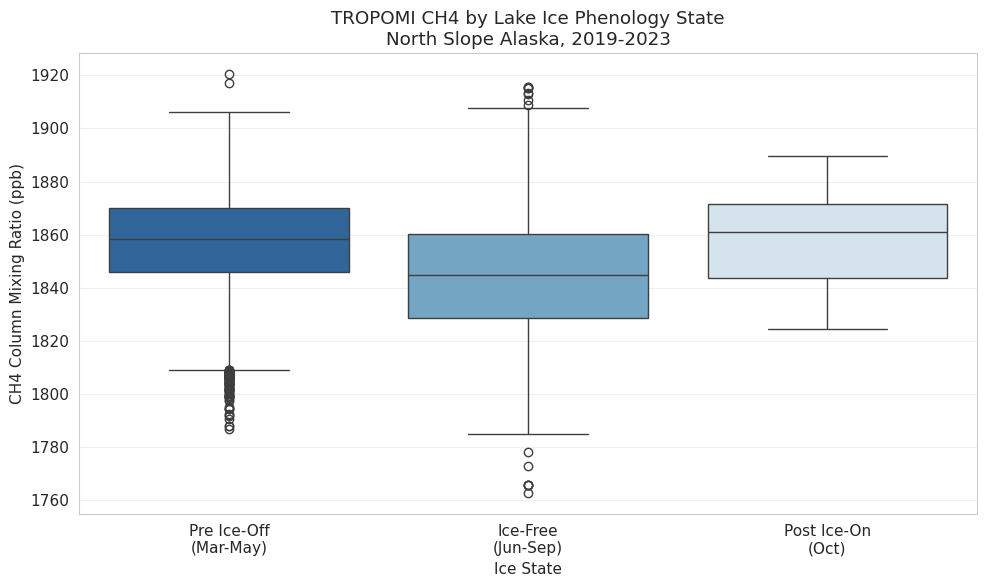

Saved: ch4_by_ice_state.png


In [14]:
# Figure 1: CH4 by Ice State (box plots)
if len(ch4_with_phenology) == 0:
    print("Skipping figure - no CH4 data available")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Order states logically
    state_order = ['pre_ice_off', 'ice_free', 'post_ice_on']
    state_labels = ['Pre Ice-Off\n(Mar-May)', 'Ice-Free\n(Jun-Sep)', 'Post Ice-On\n(Oct)']

    plot_data = ch4_with_phenology[ch4_with_phenology['ice_state'].isin(state_order)]
    
    if len(plot_data) > 0:
        sns.boxplot(data=plot_data, x='ice_state', y='ch4_ppb', order=state_order, 
                    palette=['#2166ac', '#67a9cf', '#d1e5f0'], ax=ax)

        ax.set_xticklabels(state_labels)
        ax.set_xlabel('Ice State')
        ax.set_ylabel('CH4 Column Mixing Ratio (ppb)')
        ax.set_title('TROPOMI CH4 by Lake Ice Phenology State\nNorth Slope Alaska, 2019-2023')
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/ch4_by_ice_state.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: ch4_by_ice_state.png")
    else:
        print("No valid data for box plot")

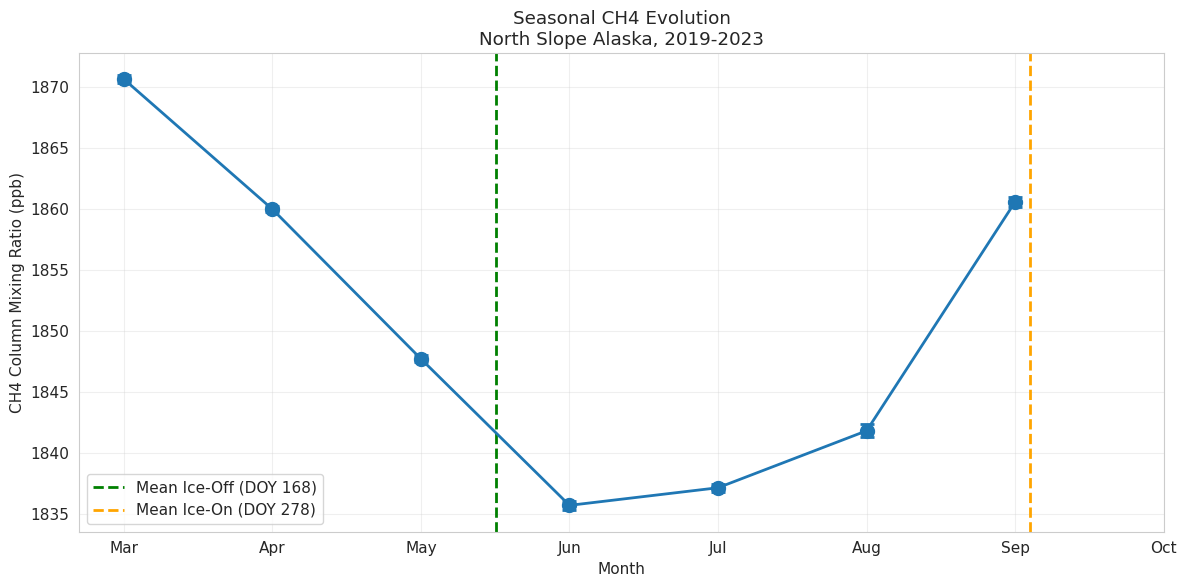

Saved: ch4_seasonal_evolution.png


In [15]:
# Figure 2: Seasonal CH4 time series
if len(ch4_with_phenology) == 0:
    print("Skipping figure - no CH4 data available")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Monthly means with error bars
    monthly_stats = ch4_with_phenology.groupby('month')['ch4_ppb'].agg(['mean', 'std', 'count']).reset_index()

    if len(monthly_stats) > 0:
        ax.errorbar(monthly_stats['month'], monthly_stats['mean'], 
                    yerr=monthly_stats['std']/np.sqrt(monthly_stats['count']),
                    fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=10)

        # Add vertical lines for typical ice-off and ice-on
        mean_ice_off = complete_phenology['ice_off_doy'].mean()
        mean_ice_on = complete_phenology['ice_on_doy'].mean()

        # Convert DOY to approximate month
        ice_off_month = mean_ice_off / 30.5
        ice_on_month = mean_ice_on / 30.5

        ax.axvline(ice_off_month, color='green', linestyle='--', linewidth=2, 
                   label=f'Mean Ice-Off (DOY {mean_ice_off:.0f})')
        ax.axvline(ice_on_month, color='orange', linestyle='--', linewidth=2,
                   label=f'Mean Ice-On (DOY {mean_ice_on:.0f})')

        ax.set_xlabel('Month')
        ax.set_ylabel('CH4 Column Mixing Ratio (ppb)')
        ax.set_title('Seasonal CH4 Evolution\nNorth Slope Alaska, 2019-2023')
        ax.set_xticks([3, 4, 5, 6, 7, 8, 9, 10])
        ax.set_xticklabels(['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'])
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/ch4_seasonal_evolution.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: ch4_seasonal_evolution.png")
    else:
        print("No monthly data available")

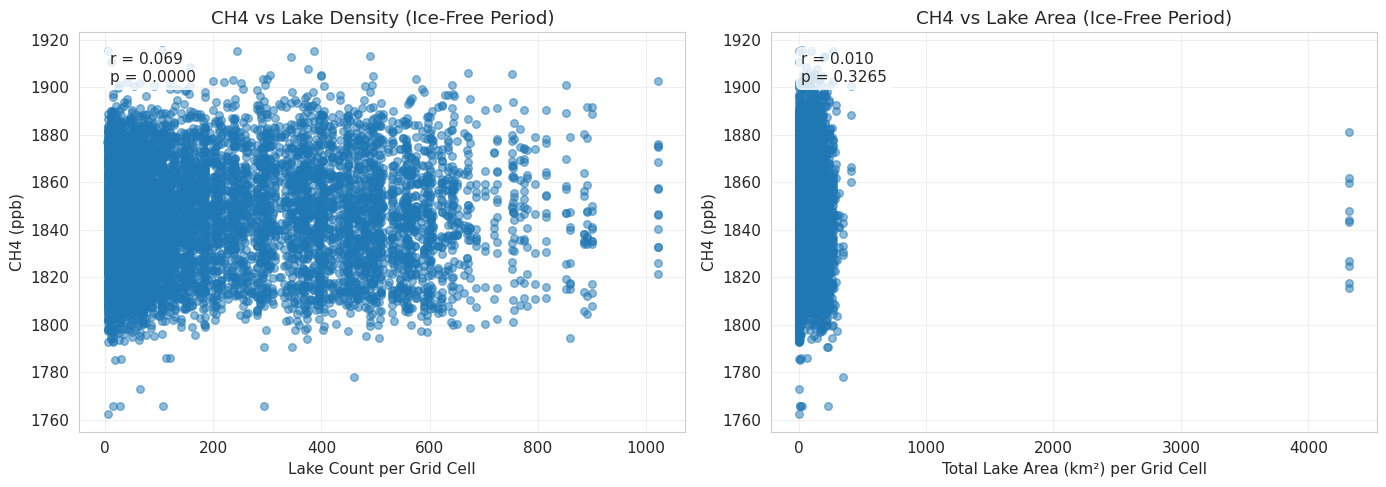

Saved: ch4_lake_density_scatter.png


In [16]:
# Figure 3: CH4 vs Lake Density scatter
if len(ch4_with_phenology) == 0:
    print("Skipping figure - no CH4 data available")
else:
    # Filter to ice-free period
    ice_free_data = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'ice_free']
    
    if len(ice_free_data) > 10:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # CH4 vs Lake Count
        ax = axes[0]
        ax.scatter(ice_free_data['lake_count'], ice_free_data['ch4_ppb'], alpha=0.5, s=30)
        valid = ice_free_data[['lake_count', 'ch4_ppb']].dropna()
        if len(valid) > 2:
            r, p = stats.pearsonr(valid['lake_count'], valid['ch4_ppb'])
            ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.4f}', transform=ax.transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlabel('Lake Count per Grid Cell')
        ax.set_ylabel('CH4 (ppb)')
        ax.set_title('CH4 vs Lake Density (Ice-Free Period)')
        ax.grid(True, alpha=0.3)

        # CH4 vs Total Lake Area
        ax = axes[1]
        ax.scatter(ice_free_data['total_lake_area_km2'], ice_free_data['ch4_ppb'], alpha=0.5, s=30)
        valid = ice_free_data[['total_lake_area_km2', 'ch4_ppb']].dropna()
        if len(valid) > 2:
            r, p = stats.pearsonr(valid['total_lake_area_km2'], valid['ch4_ppb'])
            ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.4f}', transform=ax.transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlabel('Total Lake Area (km²) per Grid Cell')
        ax.set_ylabel('CH4 (ppb)')
        ax.set_title('CH4 vs Lake Area (Ice-Free Period)')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/ch4_lake_density_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: ch4_lake_density_scatter.png")
    else:
        print(f"Insufficient ice-free data for scatter plots (n={len(ice_free_data)})")

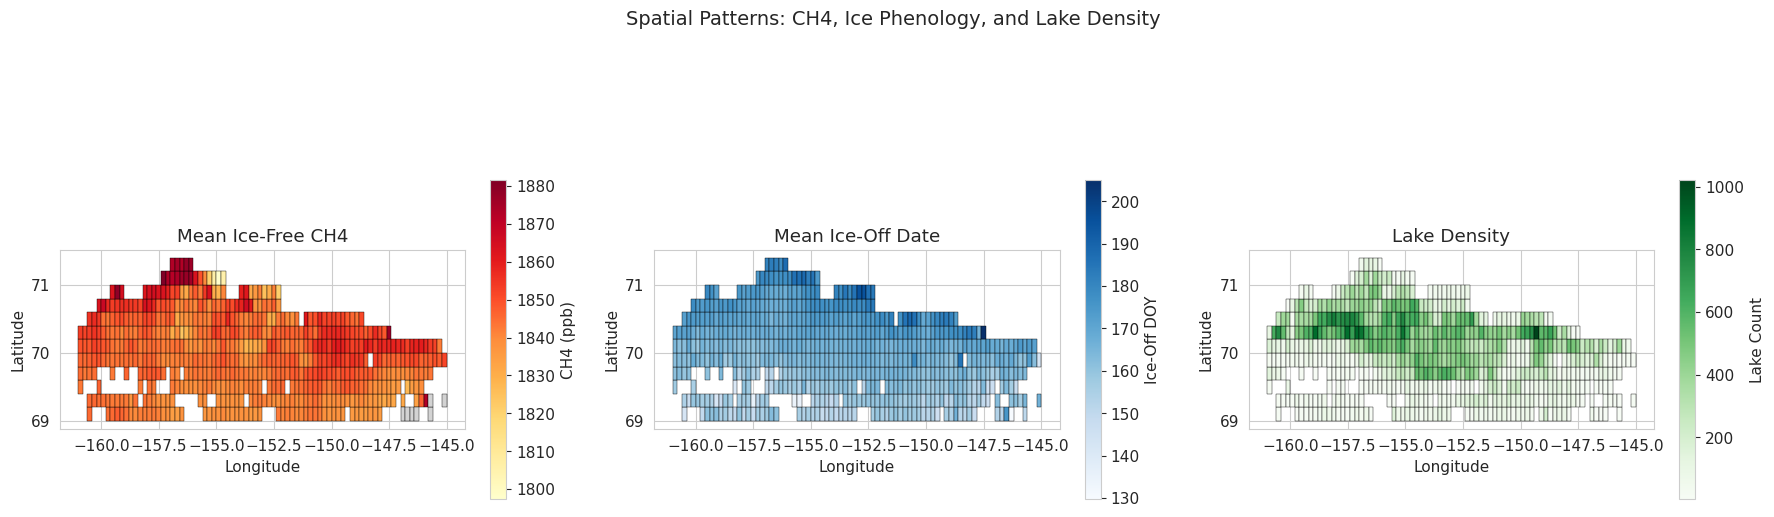

Saved: ch4_spatial_patterns.png


In [17]:
# Figure 4: Spatial map of CH4 and ice phenology
if len(ch4_with_phenology) == 0:
    print("Skipping figure - no CH4 data available")
else:
    # Compute mean CH4 per cell during ice-free period
    ice_free_ch4_by_cell = ch4_with_phenology[ch4_with_phenology['ice_state'] == 'ice_free'].groupby('cell_id')['ch4_ppb'].mean().reset_index()
    ice_free_ch4_by_cell.columns = ['cell_id', 'mean_ice_free_ch4']

    # Merge with grid
    grid_for_plot = active_cells.merge(ice_free_ch4_by_cell, on='cell_id', how='left')
    
    if grid_for_plot['mean_ice_free_ch4'].notna().sum() > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Panel A: Mean ice-free CH4
        ax = axes[0]
        grid_for_plot.plot(column='mean_ice_free_ch4', ax=ax, legend=True,
                           cmap='YlOrRd', edgecolor='black', linewidth=0.3,
                           legend_kwds={'label': 'CH4 (ppb)', 'shrink': 0.6},
                           missing_kwds={'color': 'lightgray'})
        ax.set_title('Mean Ice-Free CH4')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        # Panel B: Mean ice-off DOY
        ax = axes[1]
        grid_for_plot.plot(column='mean_ice_off_doy', ax=ax, legend=True,
                           cmap='Blues', edgecolor='black', linewidth=0.3,
                           legend_kwds={'label': 'Ice-Off DOY', 'shrink': 0.6},
                           missing_kwds={'color': 'lightgray'})
        ax.set_title('Mean Ice-Off Date')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        # Panel C: Lake density
        ax = axes[2]
        grid_for_plot.plot(column='lake_count', ax=ax, legend=True,
                           cmap='Greens', edgecolor='black', linewidth=0.3,
                           legend_kwds={'label': 'Lake Count', 'shrink': 0.6},
                           missing_kwds={'color': 'lightgray'})
        ax.set_title('Lake Density')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        plt.suptitle('Spatial Patterns: CH4, Ice Phenology, and Lake Density', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/ch4_spatial_patterns.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: ch4_spatial_patterns.png")
    else:
        print("No CH4 data available for spatial maps")

## Part 7: Export Results

Export analysis results to GCS for future use.

In [18]:
# Export CH4 grid summary
print("Exporting results to GCS...")

if len(ch4_with_phenology) == 0:
    print("No CH4 data to export.")
else:
    # CH4 monthly data per cell
    export_cols = ['cell_id', 'year', 'month', 'ch4_ppb', 'ice_state',
                   'lat_center', 'lon_center',
                   'mean_ice_off_doy', 'mean_ice_on_doy', 'mean_ice_free_days',
                   'lake_count', 'total_lake_area_km2']
    
    # Only include columns that exist
    available_cols = [c for c in export_cols if c in ch4_with_phenology.columns]
    ch4_export = ch4_with_phenology[available_cols]

    ch4_path = f'{RESULTS_GCS}/ch4_grid_monthly_2019-2023.csv'
    try:
        ch4_export.to_csv(ch4_path, index=False)
        print(f"  Exported: {ch4_path}")
        print(f"  Rows: {len(ch4_export):,}")
    except Exception as e:
        print(f"  GCS export failed: {e}")
        local_path = './ch4_grid_monthly_2019-2023.csv'
        ch4_export.to_csv(local_path, index=False)
        print(f"  Saved locally: {local_path}")

    # Annual summary per cell
    annual_summary = ch4_with_phenology.groupby(['cell_id', 'year']).agg({
        'ch4_ppb': ['mean', 'std'],
        'lat_center': 'first',
        'lon_center': 'first',
        'lake_count': 'first'
    }).reset_index()

    annual_summary.columns = ['cell_id', 'year', 'mean_ch4_ppb', 'std_ch4_ppb', 
                              'lat_center', 'lon_center', 'lake_count']

    annual_path = f'{RESULTS_GCS}/ch4_annual_by_cell_2019-2023.csv'
    try:
        annual_summary.to_csv(annual_path, index=False)
        print(f"  Exported: {annual_path}")
        print(f"  Rows: {len(annual_summary):,}")
    except Exception as e:
        print(f"  GCS export failed: {e}")
        local_path = './ch4_annual_by_cell_2019-2023.csv'
        annual_summary.to_csv(local_path, index=False)
        print(f"  Saved locally: {local_path}")

print("\nExport complete!")

Exporting results to GCS...


  Exported: gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_grid_monthly_2019-2023.csv
  Rows: 17,190
  Exported: gs://wustl-eeps-geospatial/thermokarst_lakes/results/ch4_annual_by_cell_2019-2023.csv
  Rows: 3,018

Export complete!


## Summary

This notebook analyzed the relationship between TROPOMI CH4 column concentrations and thermokarst lake ice phenology on Alaska's North Slope.

**Key Findings:**
1. CH4 concentrations during the ice-free period compared to ice-covered periods
2. Spatial patterns of CH4 in relation to lake density and phenology timing
3. Correlations between regional CH4 and lake characteristics

**Output Files:**
- `ch4_grid_monthly_2019-2023.csv`: Monthly CH4 per grid cell with phenology state
- `ch4_annual_by_cell_2019-2023.csv`: Annual CH4 summary per grid cell

**Figures Generated:**
- `ch4_analysis_grid.png`: Study area grid with lake density
- `ch4_by_ice_state.png`: Box plots of CH4 by ice phenology state
- `ch4_seasonal_evolution.png`: Monthly CH4 time series
- `ch4_lake_density_scatter.png`: CH4 vs lake metrics scatter plots
- `ch4_spatial_patterns.png`: Maps of CH4, ice-off timing, and lake density